<a href="https://colab.research.google.com/github/Naira-Mohamed-11/Blinkit-grocery-sales-analysis/blob/main/Blinkit_Grocery_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blinkit Grocery Sales Analysis
##About the Project:
This project analyzes sales transaction data from **Blinkit**, an online grocery delivery platform. The goal is to understand customer buying habits, identify high-demand products, track revenue trends, and optimize overall business performance.

##Key Focus Areas:

**Sales & Revenue**: Tracking profit trends and seeing how pricing affects sales volume.

**Customer Behavior**: Understanding buyer preferences and segmenting customers based on their purchases and feedback.

**Delivery Performance**: Evaluating shipping speeds, distances, and identifying the main reasons behind order delays.

**Inventory Management**: Monitoring stock levels and product shelf-life to prevent waste.

In [17]:
from IPython.display import Image, display
Url="https://media.fashionnetwork.com/m/7882/4ac1/77da/8a18/45bb/1fbc/2c6a/b10f/14e5/863c/863c.png"
display(Image(url=Url,height=300,width=600))

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.axes_style("whitegrid")
import warnings
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")


In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
customers = pd.read_csv("/content/drive/MyDrive/Blinkit project/blinkit_customers.csv")
orders = pd.read_csv("/content/drive/MyDrive/Blinkit project/blinkit_orders.csv")
order_item = pd.read_csv("/content/drive/MyDrive/Blinkit project/blinkit_order_items.csv")
products = pd.read_csv("/content/drive/MyDrive/Blinkit project/blinkit_products.csv")
delivary = pd.read_csv("/content/drive/MyDrive/Blinkit project/blinkit_delivery_performance.csv")
feedback = pd.read_csv("/content/drive/MyDrive/Blinkit project/blinkit_customer_feedback.csv")
markting = pd.read_csv("/content/drive/MyDrive/Blinkit project/blinkit_marketing_performance.csv")
inventory = pd.read_csv("/content/drive/MyDrive/Blinkit project/blinkit_inventory.csv")
Inventory_new = pd.read_csv("/content/drive/MyDrive/Blinkit project/blinkit_inventoryNew.csv")

reading files

In [21]:
customers.head()

,customer_id,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,97475543,Niharika Nagi,ektataneja@example.org,912987579691,"23, Nayar Path, Bihar Sharif-154625",Udupi,321865,2023-05-13,Premium,13,451.92
1,22077605,Megha Sachar,vedant45@example.com,915123179717,"51/302, Buch Chowk\nSrinagar-570271",Aligarh,149394,2024-06-18,Inactive,4,825.48
2,47822591,Hema Bahri,samiazaan@example.com,910034076149,"941\nAnne Street, Darbhanga 186125",Begusarai,621411,2024-09-25,Regular,17,1969.81
3,79726146,Zaitra Vig,ishanvi87@example.org,916264232390,"43/94, Ghosh, Alappuzha 635655",Kozhikode,826054,2023-10-04,New,4,220.09
4,57102800,Januja Verma,atideshpande@example.org,917293526596,"06\nOm, Ambarnath 477463",Ichalkaranji,730539,2024-03-22,Inactive,14,578.14


In [22]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2500 non-null   int64  
 1   customer_name      2500 non-null   object 
 2   email              2500 non-null   object 
 3   phone              2500 non-null   int64  
 4   address            2500 non-null   object 
 5   area               2500 non-null   object 
 6   pincode            2500 non-null   int64  
 7   registration_date  2500 non-null   object 
 8   customer_segment   2500 non-null   object 
 9   total_orders       2500 non-null   int64  
 10  avg_order_value    2500 non-null   float64
dtypes: float64(1), int64(4), object(6)
memory usage: 215.0+ KB


---
Data type of the registration date should be datetime  &&
Data type of customer segment must by category


In [23]:
customers['registration_date']=pd.to_datetime(customers['registration_date'])
customers["customer_segment"]=customers["customer_segment"].astype(''"category")
# customers.info()

In [24]:
orders.head()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


In [25]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB


Data type of order_date should be dateTime
& Data type of promised delivery time shold be datetime
& actual delivary time should be datetime
& data type of delivery_status should be category
& data type of paymentmethod shold be category

In [26]:
orders['order_data']=pd.to_datetime(orders['order_date'])
orders['primised_delivery_time']=pd.to_datetime(orders["promised_delivery_time"])
orders['actual_delivery_time']=pd.to_datetime(orders['actual_delivery_time'])
orders['delivery_status']=orders['delivery_status'].astype('category')
orders['payment_method']=orders['payment_method'].astype('category')


In [27]:
order_item.head()

,order_id,product_id,quantity,unit_price
0,1961864118,642612,3,517.03
1,1549769649,378676,1,881.42
2,9185164487,741341,2,923.84
3,9644738826,561860,1,874.78
4,5427684290,602241,2,976.55


In [28]:
order_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    5000 non-null   int64  
 1   product_id  5000 non-null   int64  
 2   quantity    5000 non-null   int64  
 3   unit_price  5000 non-null   float64
dtypes: float64(1), int64(3)
memory usage: 156.4 KB


In [29]:
products

,product_id,product_name,category,brand,price,mrp,margin_percentage,shelf_life_days,min_stock_level,max_stock_level
0,153019,Onions,Fruits & Vegetables,Aurora LLC,947.95,1263.93,25.0,3,13,88
1,11422,Potatoes,Fruits & Vegetables,Ramaswamy-Tata,127.16,169.55,25.0,3,20,65
2,669378,Potatoes,Fruits & Vegetables,Chadha and Sons,212.14,282.85,25.0,3,23,70
3,848226,Tomatoes,Fruits & Vegetables,Barad and Sons,209.59,279.45,25.0,3,10,51
4,890623,Onions,Fruits & Vegetables,"Sangha, Nagar and Varty",354.52,472.69,25.0,3,27,55
...,...,...,...,...,...,...,...,...,...,...
263,444361,Pain Reliever,Pharmacy,"Prakash, Bawa and Kale",822.63,1028.29,20.0,365,20,71
264,679284,Cough Syrup,Pharmacy,Pant LLC,877.89,1097.36,20.0,365,28,95
265,240179,Cough Syrup,Pharmacy,Ram-Suri,90.56,113.20,20.0,365,20,56
266,673058,Cough Syrup,Pharmacy,Balan-Madan,765.76,957.20,20.0,365,30,94


In [30]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 268 entries, 0 to 267
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         268 non-null    int64  
 1   product_name       268 non-null    object 
 2   category           268 non-null    object 
 3   brand              268 non-null    object 
 4   price              268 non-null    float64
 5   mrp                268 non-null    float64
 6   margin_percentage  268 non-null    float64
 7   shelf_life_days    268 non-null    int64  
 8   min_stock_level    268 non-null    int64  
 9   max_stock_level    268 non-null    int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 21.1+ KB


In [31]:
products['category']=products['category'].astype('category')

In [32]:
delivary.head()

,order_id,delivery_partner_id,promised_time,actual_time,delivery_time_minutes,distance_km,delivery_status,reasons_if_delayed
0,1961864118,63230,2024-07-17 08:52:01,2024-07-17 08:47:01,-5.0,0.96,On Time,NaN
1,1549769649,14983,2024-05-28 13:25:29,2024-05-28 13:27:29,2.0,0.98,On Time,Traffic
2,9185164487,39859,2024-09-23 13:25:12,2024-09-23 13:29:12,4.0,3.83,On Time,Traffic
3,9644738826,61497,2023-11-24 16:34:56,2023-11-24 16:33:56,-1.0,2.76,On Time,NaN
4,5427684290,84315,2023-11-20 05:17:39,2023-11-20 05:18:39,1.0,2.63,On Time,Traffic


In [33]:
delivary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               5000 non-null   int64  
 1   delivery_partner_id    5000 non-null   int64  
 2   promised_time          5000 non-null   object 
 3   actual_time            5000 non-null   object 
 4   delivery_time_minutes  5000 non-null   float64
 5   distance_km            5000 non-null   float64
 6   delivery_status        5000 non-null   object 
 7   reasons_if_delayed     3098 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 312.6+ KB


In [34]:
delivary['promised_time']=pd.to_datetime(delivary['promised_time'])
delivary['actual_time']=pd.to_datetime(delivary['actual_time'])
delivary['delivery_status']=delivary['delivery_status'].astype('category')

In [35]:
feedback.head()

,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,4823104,9644738826,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,3537464,5427684290,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


In [36]:
feedback.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   feedback_id        5000 non-null   int64 
 1   order_id           5000 non-null   int64 
 2   customer_id        5000 non-null   int64 
 3   rating             5000 non-null   int64 
 4   feedback_text      5000 non-null   object
 5   feedback_category  5000 non-null   object
 6   sentiment          5000 non-null   object
 7   feedback_date      5000 non-null   object
dtypes: int64(4), object(4)
memory usage: 312.6+ KB


In [37]:
feedback['feedback_date'] = pd.to_datetime(feedback['feedback_date'])
feedback['feedback_category'] = feedback['feedback_category'].astype('category')
feedback['sentiment'] = feedback['sentiment'].astype('category')

In [38]:
markting.head()

,campaign_id,campaign_name,date,target_audience,channel,impressions,clicks,conversions,spend,revenue_generated,roas
0,548299,New User Discount,2024-11-05,Premium,App,3130,163,78,1431.85,4777.75,3.60
1,390914,Weekend Special,2024-11-05,Inactive,App,3925,494,45,4506.34,6238.11,2.98
2,834385,Festival Offer,2024-11-05,Inactive,Email,7012,370,78,4524.23,2621.00,2.95
3,241523,Flash Sale,2024-11-05,Inactive,SMS,1115,579,86,3622.79,2955.00,2.84
4,595111,Membership Drive,2024-11-05,New Users,Email,7172,795,54,2888.99,8951.81,2.22


In [39]:
markting.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   campaign_id        5400 non-null   int64  
 1   campaign_name      5400 non-null   object 
 2   date               5400 non-null   object 
 3   target_audience    5400 non-null   object 
 4   channel            5400 non-null   object 
 5   impressions        5400 non-null   int64  
 6   clicks             5400 non-null   int64  
 7   conversions        5400 non-null   int64  
 8   spend              5400 non-null   float64
 9   revenue_generated  5400 non-null   float64
 10  roas               5400 non-null   float64
dtypes: float64(3), int64(4), object(4)
memory usage: 464.2+ KB


In [40]:
markting['date'] = pd.to_datetime(markting['date'])
markting['target_audience'] = markting['target_audience'].astype('category')
markting['channel'] = markting['channel'].astype('category')

In [41]:
inventory.head()

,product_id,date,stock_received,damaged_stock
0,153019,17-03-2023,4,2
1,848226,17-03-2023,4,2
2,965755,17-03-2023,1,0
3,39154,17-03-2023,4,0
4,34186,17-03-2023,3,2


In [42]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75172 entries, 0 to 75171
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      75172 non-null  int64 
 1   date            75172 non-null  object
 2   stock_received  75172 non-null  int64 
 3   damaged_stock   75172 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 2.3+ MB


In [43]:
inventory['date'] = pd.to_datetime(inventory['date'],dayfirst=True)

In [44]:
Inventory_new.head()

,product_id,date,stock_received,damaged_stock
0,153019,Mar-23,4,1
1,848226,Mar-23,4,1
2,965755,Mar-23,1,0
3,39154,Mar-23,4,0
4,34186,Mar-23,3,1


In [45]:
Inventory_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18105 entries, 0 to 18104
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      18105 non-null  int64 
 1   date            18105 non-null  object
 2   stock_received  18105 non-null  int64 
 3   damaged_stock   18105 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 565.9+ KB


In [46]:
import pandas as pd
full_inventory = pd.concat([inventory, Inventory_new], ignore_index=True)
full_inventory = full_inventory.drop_duplicates(subset=['product_id'])
full_inventory.head()

,product_id,date,stock_received,damaged_stock
0,153019,2023-03-17 00:00:00,4,2
1,848226,2023-03-17 00:00:00,4,2
2,965755,2023-03-17 00:00:00,1,0
3,39154,2023-03-17 00:00:00,4,0
4,34186,2023-03-17 00:00:00,3,2


In [47]:
delivary.isnull().sum()

,0
order_id,0
delivery_partner_id,0
promised_time,0
actual_time,0
delivery_time_minutes,0
distance_km,0
delivery_status,0
reasons_if_delayed,1902


In [48]:
delivary['reasons_if_delayed'].value_counts()

,count
reasons_if_delayed,
Traffic,3098


In [49]:
delivary['reasons_if_delayed']=delivary['reasons_if_delayed'].fillna("Not Specified")

Data integration

In [50]:
# The integration of orders table and Customers table

order_customer=pd.merge(orders,customers,on='customer_id',how='left')
order_customer.head()
# order_customer.info()
# order_customer.isnull().sum()

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,...,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,Urishilla Hegde,ydeo@example.org,910400446367,"H.No. 330\nRana Path, Sagar 712033",Allahabad,911359,2024-09-02,Regular,13,749.95
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,Ranveer Mahal,phegde@example.org,912292591574,"49, Sarkar Zila, Navi Mumbai-077374",Thrissur,856100,2023-11-07,New,5,958.06
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,Aarna Bawa,kondajagdish@example.com,912719661653,"14/351, Agarwal Path\nMedininagar 636193",Vellore,117423,2024-01-05,Inactive,4,327.93
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,Aayush Sengupta,lekha10@example.com,913367647372,"20/47\nRatta Chowk, Sonipat-022522",Gaya,288459,2023-12-25,Premium,5,273.38
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,Vansha Kuruvilla,xalak62@example.com,912910638833,"H.No. 68, Gaba Road\nKhandwa 040880",Asansol,149383,2024-10-02,Premium,14,763.10


In [51]:
# The integration of order_id ,order_item and products
sales_data = order_item.merge(products, on='product_id') \
.merge(orders, on='order_id')
sales_data.head()
# sales_data.info()

,order_id,product_id,quantity,unit_price,product_name,category,brand,price,mrp,margin_percentage,...,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,order_data,primised_delivery_time
0,1961864118,642612,3,517.03,Pet Treats,Pet Care,Pillay-Ahuja,517.03,795.43,35.0,...,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,2024-07-17 08:34:01,2024-07-17 08:52:01
1,1549769649,378676,1,881.42,Orange Juice,Cold Drinks & Juices,Baral-Kamdar,881.42,1259.17,30.0,...,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,2024-05-28 13:14:29,2024-05-28 13:25:29
2,9185164487,741341,2,923.84,Eggs,Dairy & Breakfast,Prasad LLC,923.84,1154.80,20.0,...,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,2024-09-23 13:07:12,2024-09-23 13:25:12
3,9644738826,561860,1,874.78,Orange Juice,Cold Drinks & Juices,Gupta Ltd,874.78,1249.69,30.0,...,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,2023-11-24 16:16:56,2023-11-24 16:34:56
4,5427684290,602241,2,976.55,Nuts,Snacks & Munchies,Bahl-Pau,976.55,1502.38,35.0,...,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,2023-11-20 05:00:39,2023-11-20 05:17:39


In [52]:
#The integration of orders ,delivary and feedback
orders_experience=orders.merge(delivary,on='order_id').merge(feedback,on='order_id')
orders_experience.head()
# orders_experience.info()


,order_id,customer_id_x,order_date,promised_delivery_time,actual_delivery_time,delivery_status_x,order_total,payment_method,delivery_partner_id_x,store_id,...,distance_km,delivery_status_y,reasons_if_delayed,feedback_id,customer_id_y,rating,feedback_text,feedback_category,sentiment,feedback_date
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,0.96,On Time,Not Specified,2234710,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,0.98,On Time,Traffic,5450964,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,3.83,On Time,Traffic,482108,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,2.76,On Time,Not Specified,4823104,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,2.63,On Time,Traffic,3537464,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


In [53]:
print(inventory.columns)
print(Inventory_new.columns)

Index(['product_id', 'date', 'stock_received', 'damaged_stock'], dtype='object')
Index(['product_id', 'date', 'stock_received', 'damaged_stock'], dtype='object')


Explatory data analysis

### Marketing Analysis

In [54]:
#Arranging campaigns from highest to lowest in Return on Ad Spend (ROAS)
roas_analysis=markting.sort_values(by='roas',ascending=False)
roas_analysis[['campaign_name', 'channel', 'roas']]

,campaign_name,channel,roas
2448,New User Discount,App,4.0
5276,Festival Offer,Email,4.0
97,Email Campaign,Social Media,4.0
667,Weekend Special,Social Media,4.0
4338,New User Discount,Social Media,4.0
...,...,...,...
2244,Flash Sale,Social Media,1.5
4397,Category Promotion,Email,1.5
3242,Festival Offer,Social Media,1.5
1763,Referral Program,SMS,1.5


--- Average ROAS per Channel ---
     channel     roas
         App 2.754301
Social Media 2.749188
       Email 2.748861
         SMS 2.710112


--- Average ROAS per Campaign Type ---
        campaign_name     roas
       Email Campaign 2.777067
       Festival Offer 2.765917
App Push Notification 2.760817
    New User Discount 2.754950
     Referral Program 2.743450
      Weekend Special 2.743333
     Membership Drive 2.719833
           Flash Sale 2.711067
   Category Promotion 2.689967




/tmp/ipykernel_1795/3580084767.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  channel_efficiency=markting.groupby('channel')['roas'].mean().reset_index()


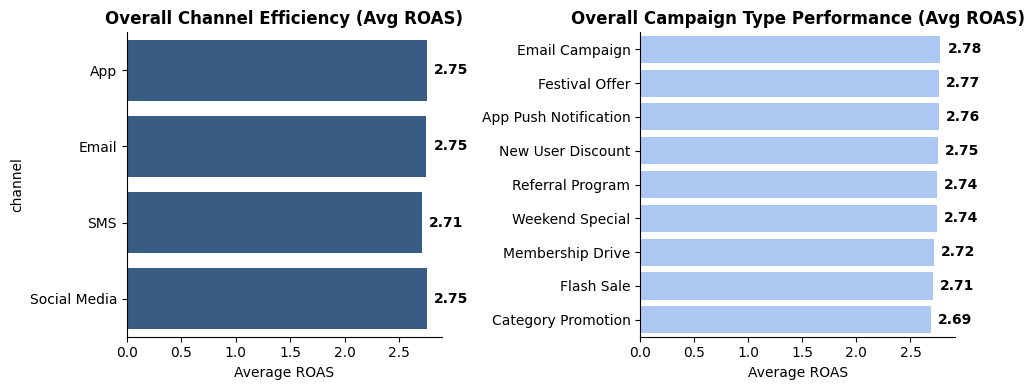

In [55]:
channel_efficiency=markting.groupby('channel')['roas'].mean().reset_index()
channel_efficiency = channel_efficiency.sort_values(by='roas', ascending=False)
print("--- Average ROAS per Channel ---")
print(channel_efficiency.to_string(index=False))
print("\n" + "="*50 + "\n")

campaign_type_efficiency = markting.groupby('campaign_name')['roas'].mean().reset_index()
campaign_type_efficiency = campaign_type_efficiency.sort_values(by='roas', ascending=False)

print("--- Average ROAS per Campaign Type ---")
print(campaign_type_efficiency.to_string(index=False))
print("\n" + "="*50 + "\n")

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
#Channels
sns.barplot(x='roas', y='channel', data=channel_efficiency, color='#2b5c8f', ax=ax1)
ax1.bar_label(ax1.containers[0], fmt='%.2f', padding=5, fontweight='bold')
ax1.set_title('Overall Channel Efficiency (Avg ROAS)', fontweight='bold')
ax1.set_xlabel('Average ROAS')

#campign
sns.barplot(x='roas', y='campaign_name', data=campaign_type_efficiency, color='#a1c4fd', ax=ax2)
ax2.bar_label(ax2.containers[0], fmt='%.2f', padding=5, fontweight='bold')
ax2.set_title('Overall Campaign Type Performance (Avg ROAS)', fontweight='bold')
ax2.set_xlabel('Average ROAS')
ax2.set_ylabel('')

sns.despine()
plt.tight_layout()
plt.show()

###(Observations on Aggregated Data)

* **Uniform Channel Performance:** At an aggregate level, **App**, **Email**, and **Social Media** all yield an identical average ROAS of **2.75**, with **SMS** slightly trailing at **2.71**. This lack of variance suggests that no single channel outperforms the others on a macro scale.
* **Stable Campaign Baselines:** Similarly, overall campaign types perform within a very narrow window, ranging strictly between **2.69** (Category Promotion) and **2.78** (Email Campaign).

**The "Aggregation Paradox" (Why we need granular view):**
  While this high-level view suggests uniform performance across the board, it actually **masks the true dynamics** of our marketing efforts. High-performing combinations and low-performing failures are canceling each other out within these broad averages.
  
  *This justifies why we must dive deeper into the **Campaign + Channel combinations** (as visualized below) to uncover the hidden breakthroughs and budget drains.*

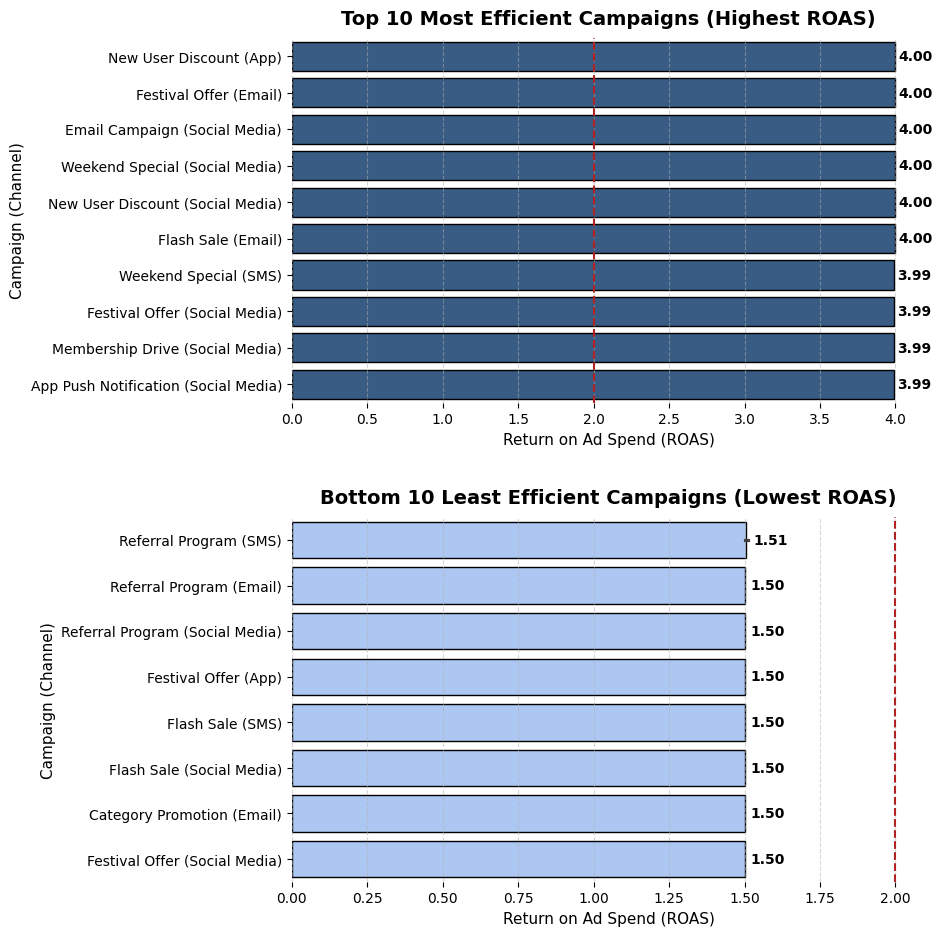

In [56]:
roas_analysis['campaign_channel'] = roas_analysis['campaign_name'].astype(str) + " (" + roas_analysis['channel'].astype(str) + ")"
top_10=roas_analysis.head(10)
bottom_10=roas_analysis.tail(10)

fig,(ax1,ax2)=plt.subplots(nrows=2,ncols=1,figsize=(10,10))
# Top 10 graph :
sns.barplot(
    x='roas',
    y='campaign_channel',
    data=top_10,
    #palette='Blues_r'
    color='#2b5c8f',
    edgecolor='black',
    ax=ax1
)
ax1.axvline(x=2.0, color='firebrick', linestyle='--', linewidth=1.5, label='Target ROAS (2.0)')
for i, p in enumerate(ax1.patches):
    val = top_10.iloc[i]['roas']
    ax1.text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax1.set_title('Top 10 Most Efficient Campaigns (Highest ROAS)', fontsize=14, pad=10, fontweight='bold')
ax1.set_xlabel('Return on Ad Spend (ROAS)', fontsize=11)
ax1.set_ylabel('Campaign (Channel)', fontsize=11)
ax1.grid(axis='x', linestyle='--', alpha=0.5)

# bottom 10
sns.barplot(
    x='roas',y='campaign_channel',
    data=bottom_10,
    color='#a1c4fd',
    edgecolor='black',
    ax=ax2)

ax2.axvline(x=2.0, color='firebrick', linestyle='--', linewidth=1.5, label='Target ROAS (2.0)')
for i, p in enumerate(ax2.patches):
    val = bottom_10.iloc[i]['roas']
    ax2.text(val + 0.02, i, f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax2.set_title('Bottom 10 Least Efficient Campaigns (Lowest ROAS)', fontsize=14, pad=10, fontweight='bold')
ax2.set_xlabel('Return on Ad Spend (ROAS)', fontsize=11)
ax2.set_ylabel('Campaign (Channel)', fontsize=11)
ax2.grid(axis='x', linestyle='--', alpha=0.5)


sns.despine(left=True, bottom=True)
plt.tight_layout(pad=3.0)
plt.show()

### Actionable Insights from Campaign Performance (ROAS)

* **Top-Tier Performance (The 4.0x Club):**
  * Multiple campaigns have reached a stellar ceiling of **4.00 ROAS**, demonstrating excellent efficiency.
  * Key wins include the **New User Discount (App)** and **Festival Offer (Email)**, confirming that welcoming incentives and targeted email marketing remain our strongest revenue drivers.
  * **Social Media Campaigns** show a high success rate when paired with specific urgency-driven offers like the **Weekend Special** and **Email Campaigns**.

* **Underperforming Track (The 1.5x Floor):**
  * A significant cluster of campaigns is hitting a low baseline of **1.50 - 1.51 ROAS**, falling below our **Target ROAS Benchmark of 2.0**.
  * **Referral Programs** across all channels (**SMS, Email, and Social Media**) are consistently underperforming, indicating that the referral mechanics or the incentives offered to users are not appealing enough to drive strong conversion.
  * Broader, non-personalized efforts like **Category Promotion (Email)** and certain **Flash Sales/Festival Offers on Social Media** are draining budget with minimal return, likely due to poor audience targeting.

---

### Strategic Recommendations

1. **Budget Reallocation:** Immediately shift ad spend away from the underperforming 1.50 ROAS campaigns (especially SMS and Referral channels) and reinvest it into the top-performing New User and Email segments to maximize overall profitability.
2. **Revamp Referral Incentives:** Address the systemic failure of the Referral Programs by restructuring the rewards or pausing the campaigns until a new strategy is developed.
3. **Enhance Personalization:** Replace general **Category Promotions** with automated, personalized email flows based on user behavior to push the email performance even higher.

/tmp/ipykernel_1795/155602005.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='channel',y='conversion_rate',data=markting,palette='viridis')


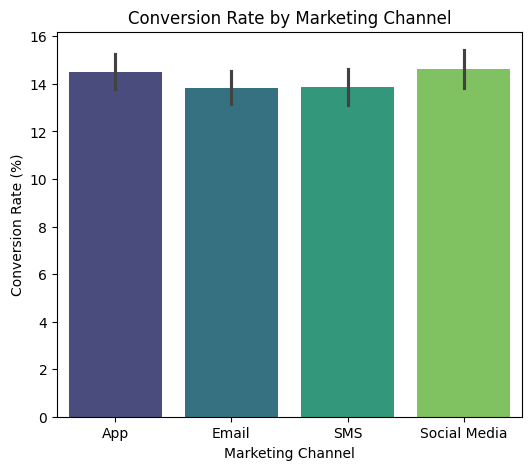

In [57]:
#Determining the best marketing channel in terms of Conversion Rate (CR)
markting['conversion_rate']=(markting['conversions']/markting['clicks'])*100
plt.figure(figsize=(6,5))
sns.barplot(x='channel',y='conversion_rate',data=markting,palette='viridis')
plt.title('Conversion Rate by Marketing Channel')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Marketing Channel')
plt.show()

### Conversion Rate (CR) Analysis Insights

* **Highly Uniform Conversion Rates:** All marketing channels exhibit very close conversion capabilities, hovering tightly between **13.8% and 14.6%**. **Social Media** leads by a hair, closely followed by the **App**.
* **Consistent User Intent:** The minimal variance indicates that our messaging and landing pages successfully persuade users to convert at similar rates across all platforms.

* **The Ad Spend Paradox (CR vs. ROAS):**
  While **Social Media** boasts the highest conversion rate (~14.6%), it doesn't vastly outperform other channels in total ROAS macro-averages. This heavily implies that while Social Media is highly effective at driving actions, it suffers from **higher customer acquisition costs (CAC)** or lower average order values, which dilutes its final profitability compared to lower-cost channels like **Email**.

Analysis of Inventory

In [58]:
inventory['damage_status'] = np.where(
    inventory['damaged_stock'] > inventory['stock_received'],
    'Old Stock Clearance',
    'Normal/New Stock Damage'
)


product_behavior = inventory.groupby(['product_id', 'damage_status']).size().unstack(fill_value=0)

product_behavior = product_behavior.sort_values(by='Old Stock Clearance', ascending=False)
print(product_behavior.head(5))

inventory['date'] = pd.to_datetime(inventory['date'])

inventory['day_of_month'] = inventory['date'].dt.day
inventory['month_year'] = inventory['date'].dt.to_period('M')

time_behavior = inventory.groupby(['day_of_month', 'damage_status']).size().unstack(fill_value=0)
print(time_behavior)

damage_status  Normal/New Stock Damage  Old Stock Clearance
product_id                                                 
767398                             108                  148
709916                             102                  137
692985                             149                  136
473929                             131                  136
448752                             105                  135
damage_status  Normal/New Stock Damage  Old Stock Clearance
day_of_month                                               
1                                 1505                 1001
2                                 1578                  980
3                                 1562                  988
4                                 1564                  999
5                                 1522                  928
6                                 1487                  942
7                                 1480                  914
8                                 1485  

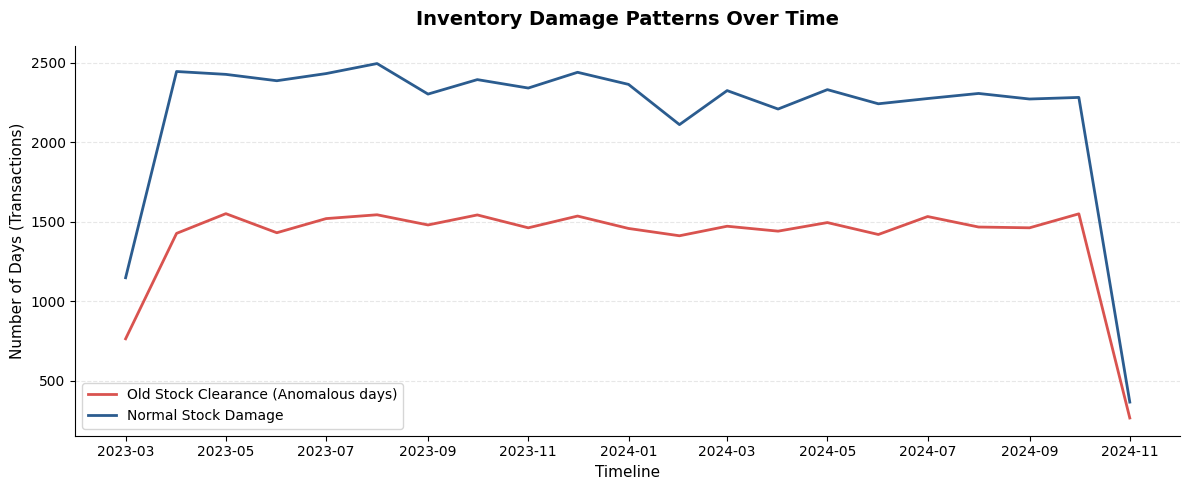

In [59]:
monthly_trend = inventory.groupby(['month_year', 'damage_status']).size().unstack(fill_value=0)
monthly_trend.index = monthly_trend.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(monthly_trend.index, monthly_trend['Old Stock Clearance'], color='#d9534f', label='Old Stock Clearance (Anomalous days)', linewidth=2)
plt.plot(monthly_trend.index, monthly_trend['Normal/New Stock Damage'], color='#2b5c8f', label='Normal Stock Damage', linewidth=2)

plt.title('Inventory Damage Patterns Over Time', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Timeline', fontsize=11)
plt.ylabel('Number of Days (Transactions)', fontsize=11)
plt.legend()
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

###Analysis of Delivery

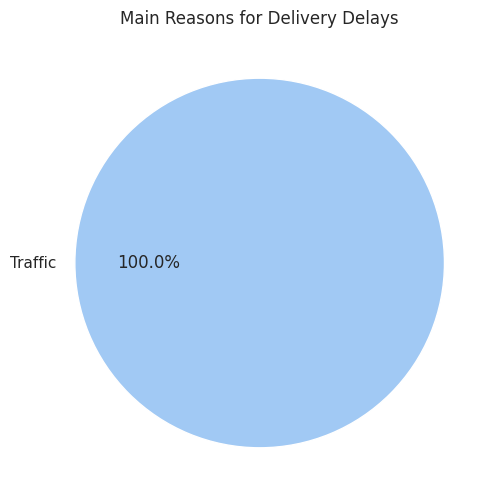

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns


orders_experience['delivery_status_x'] = orders_experience['delivery_status_x'].astype(str).str.strip()


delayed_orders = orders_experience[
    (orders_experience['delivery_status_x'] != 'On Time') &
    (orders_experience['reasons_if_delayed'].notna()) &
    (orders_experience['reasons_if_delayed'] != 'Not Specified')
]


delay_reasons = delayed_orders['reasons_if_delayed'].value_counts()


if not delay_reasons.empty:
    plt.figure(figsize=(6, 6))
    delay_reasons.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    plt.title('Main Reasons for Delivery Delays')
    plt.ylabel('')
    plt.show()
else:
    print("Notice: There are no delayed orders in the current data to clarify the delay reasons!")

       delivery_status_x    rating
0                On Time  3.332565
1  Significantly Delayed  3.326572
2       Slightly Delayed  3.392478


/tmp/ipykernel_1795/1621520547.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rating_vs_delivery, x='delivery_status_x', y='rating', palette='Set2')


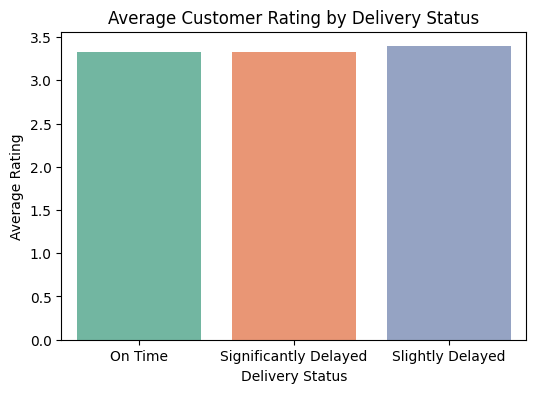

In [61]:
rating_vs_delivery = orders_experience.groupby('delivery_status_x')['rating'].mean().reset_index()
print(rating_vs_delivery)


plt.figure(figsize=(6, 4))
sns.barplot(data=rating_vs_delivery, x='delivery_status_x', y='rating', palette='Set2')
plt.title('Average Customer Rating by Delivery Status')
plt.ylabel('Average Rating')
plt.xlabel('Delivery Status')
plt.show()

Percentage frequency of each star rating (1 to 5) by delivery status
rating                      1       2       3       4       5
delivery_status_x                                            
On Time                11.67%   10.2%  27.38%   34.7%  16.05%
Significantly Delayed  10.14%  11.97%  30.22%  30.43%  17.24%
Slightly Delayed         8.2%  12.05%  28.83%  34.14%  16.78%




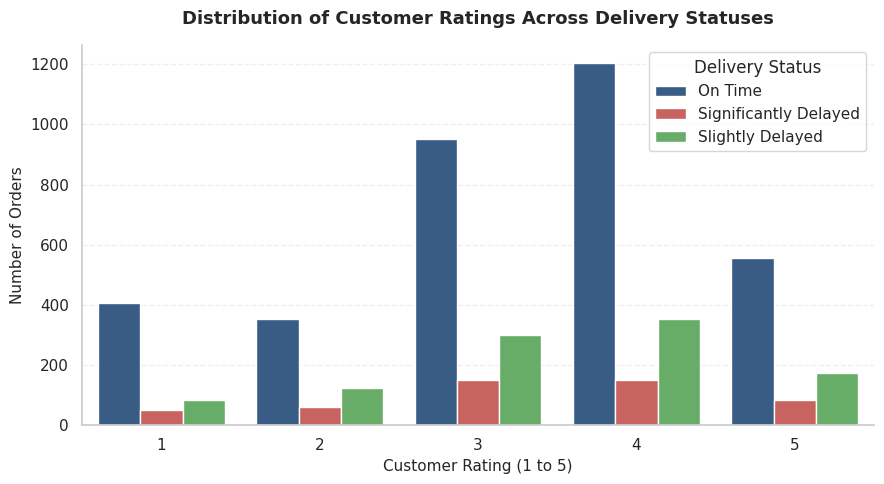

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#Rating Distribution Percentage
print("Percentage frequency of each star rating (1 to 5) by delivery status")

rating_distribution = orders_experience.groupby(['delivery_status_x', 'rating']).size().unstack(fill_value=0)

rating_dist_pct = rating_distribution.div(rating_distribution.sum(axis=1), axis=0) * 100

print(rating_dist_pct.round(2).astype(str) + '%')
print("\n" + "="*50 + "\n")


plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=orders_experience,
    x='rating',
    hue='delivery_status_x',
    palette=['#2b5c8f', '#d9534f', '#5cb85c']
)

plt.title('Distribution of Customer Ratings Across Delivery Statuses', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Customer Rating (1 to 5)', fontsize=11)
plt.ylabel('Number of Orders', fontsize=11)
plt.legend(title='Delivery Status', frameon=True)

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Key Findings from Rating Distribution Analysis

* **The Paradox Uncovered:** The countplot confirms why the average rating was identical across all delivery statuses. The distribution shape for delayed orders (both slight and significant) perfectly mirrors the 'On Time' orders, with peaks consistently at 3 and 4 stars.
* **Product Quality Dominance:** Customers in this dataset clearly isolate their product satisfaction from the logistics experience. A delayed delivery does not push the customer to leave a 1-star review, indicating strong product loyalty or product-centric rating behavior.
* **Healthy Logistics Operations:** The volume of 'On Time' shipments vastly outnumbers delayed shipments across all rating brackets, proving that delays are rare, isolated anomalies in the supply chain rather than systemic failures.

/tmp/ipykernel_1795/2935150345.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_sales = sales_data.groupby('category')['order_total'].sum().reset_index()
/tmp/ipykernel_1795/2935150345.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_sales.sort_values(by='order_total', ascending=False), x='order_total', y='category', palette='magma')


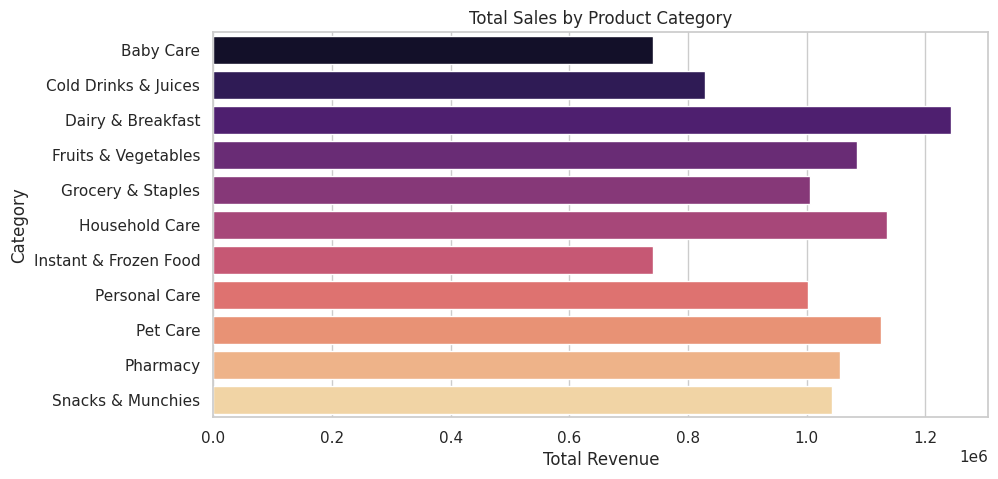

In [76]:
#Calculating total sales per product category
category_sales = sales_data.groupby('category')['order_total'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=category_sales.sort_values(by='order_total', ascending=False), x='order_total', y='category', palette='magma')
plt.title('Total Sales by Product Category')
plt.xlabel('Total Revenue')
plt.ylabel('Category')
plt.show()

### Revenue Analysis by Product Category

* **Core Revenue Driver:** `Dairy & Breakfast` stands out as the highest-performing category, generating over **1.2M** in total revenue. This emphasizes its critical role in daily customer retention.
* **Surprising High-Performers:** Categories like `Household Care` and `Pet Care` are performing exceptionally well, closely matching essential categories like `Fruits & Vegetables` at around **1.1M+**.
* **Growth Opportunities:** `Baby Care` and `Instant & Frozen Food` are currently trailing at the bottom (~740K). These segments represent an untapped opportunity for targeted marketing campaigns or bundle offers to stimulate demand.

/tmp/ipykernel_1795/599105715.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_sales = sales_data.groupby('category')['order_total'].sum().reset_index()


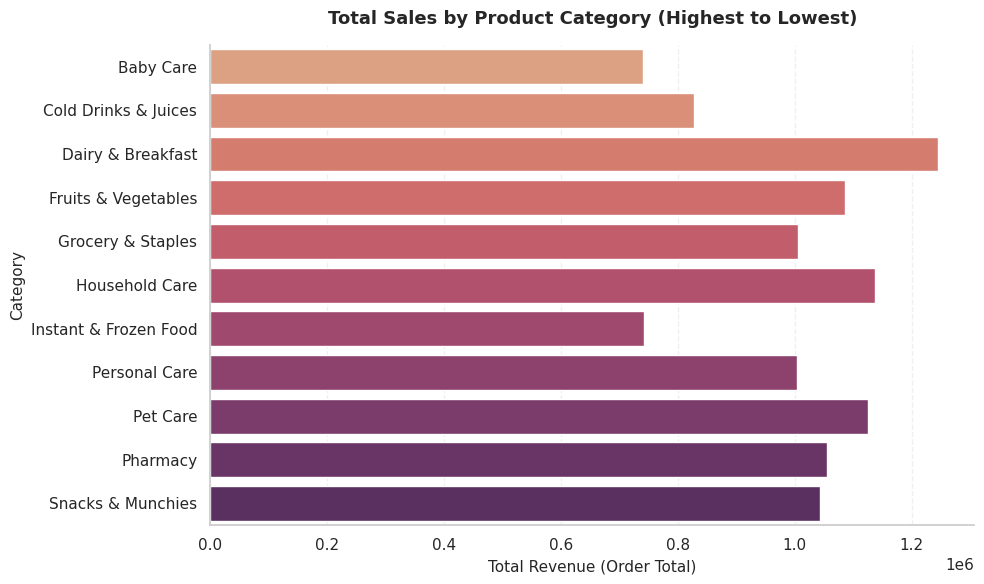

In [78]:
#Sales by Product Category
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

category_sales = sales_data.groupby('category')['order_total'].sum().reset_index()

category_sales_sorted = category_sales.sort_values(by='order_total', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_sales_sorted,
    x='order_total',
    y='category',
    hue='category',
    palette='flare',
    legend=False
)

plt.title('Total Sales by Product Category (Highest to Lowest)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (Order Total)', fontsize=11)
plt.ylabel('Category', fontsize=11)

sns.despine()
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Key Insights: Sales by Product Category

Based on the total revenue visualization, here are the main takeaways:

> **Top Revenue Driver:** The **Dairy & Breakfast** category is the clear market leader, generating the highest total revenue across the platform.

> **High-Performing Segments:** **Household Care** and **Pet Care** follow closely as major revenue contributors, showing strong consumer demand.

> **Underperforming Categories:** **Baby Care** and **Instant & Frozen Food** generated the lowest revenue, highlighting potential areas for targeted marketing campaigns or product expansion.

> **Stable Core Demand:** Most middle categories (such as *Fruits & Vegetables*, *Pharmacy*, and *Snacks*) show a steady and well-balanced distribution of sales.

---

 **Business Recommendation:** To boost overall profitability, the marketing team should launch targeted promotions for underperforming sections like **Baby Care**. Concurrently, logistics and inventory management must ensure that **Dairy & Breakfast** items are always fully stocked to avoid losing sales on high-demand products.

In [65]:
# Why do customers rate 3 stars?
low_ratings=orders_experience[orders_experience['rating']<=3]
category_issues=low_ratings.groupby(['feedback_category','sentiment']).size().unstack(fill_value=0)
print("Reasons for complaints in ratings of 3 stars or lowers")
print(category_issues.sort_values(by="Negative",ascending=False))


Reasons for complaints in ratings of 3 stars or lowers
sentiment          Negative  Neutral  Positive
feedback_category                             
Product Quality         432      214         0
Customer Service        417      197         0
Delivery                405      229         0
App Experience          388      194         0


/tmp/ipykernel_1795/890845028.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_issues=low_ratings.groupby(['feedback_category','sentiment']).size().unstack(fill_value=0)


<Figure size 1000x600 with 0 Axes>

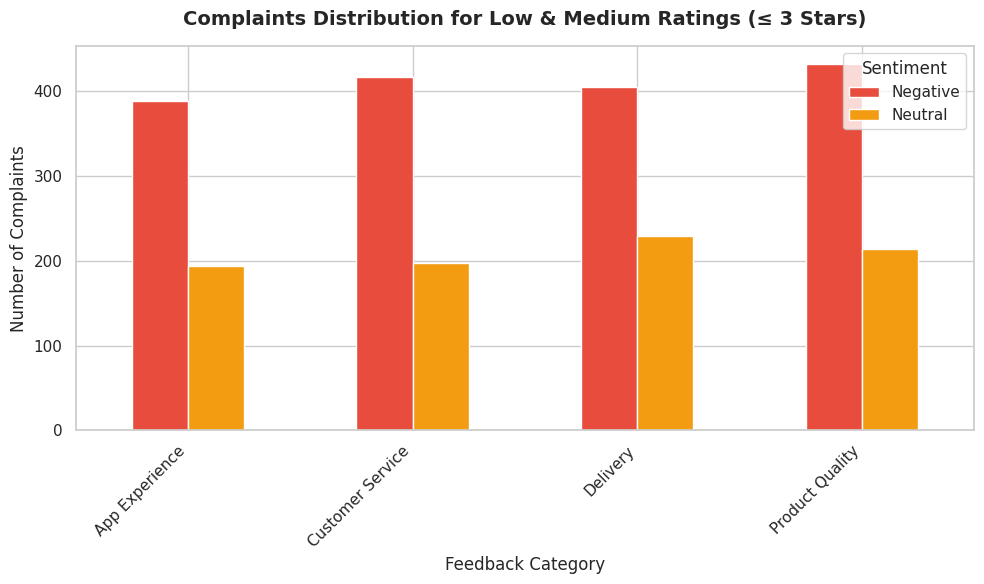

In [66]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,6))

category_issues[['Negative','Neutral']].plot(
    kind='bar',
    figsize=(10,6),
    color=['#e74c3c', '#f39c12']
)

plt.title('Complaints Distribution for Low & Medium Ratings (≤ 3 Stars)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Feedback Category', fontsize=12)
plt.ylabel('Number of Complaints', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')

plt.tight_layout()
plt.show()

### Key Insights: Complaints Analysis for Ratings $\le$ 3 Stars

Based on the feedback analysis for low-to-medium ratings, here are the core findings:

> **Product Quality is the Top Issue:** **Product Quality** recorded the highest number of strictly **Negative** complaints (432), indicating that items damaged upon arrival or poor product conditions are the primary drivers of low ratings.

> **Widespread Operational Friction:** **Customer Service** (417) and **Delivery** (405) follow closely behind. This shows a significant bottleneck in delivery times and support responsiveness.

> **App Experience Needs Optimization:** Although it ranks fourth, **App Experience** still holds 388 negative feedback counts, showing that users face technical issues while placing orders.

---

**Business Recommendation:** The company should prioritize stricter quality checks with suppliers and vendors to tackle the **Product Quality** issue. Additionally, refining delivery partner efficiency will directly cut down the high volume of delivery-related complaints.

In [67]:
#Actual delay in minutes
orders_experience['promised_delivery_time']=pd.to_datetime(orders_experience['promised_delivery_time'])
orders_experience['actual_delivery_time'] = pd.to_datetime(orders_experience['actual_delivery_time'])

orders_experience['delay in minutes']=(orders_experience['actual_delivery_time']-orders_experience['promised_delivery_time']).dt.total_seconds()/60
print(orders_experience.groupby('rating')['delay in minutes'].mean())

rating
1    3.825926
2    4.973978
3    4.719599
4    4.264052
5    4.401961
Name: delay in minutes, dtype: float64


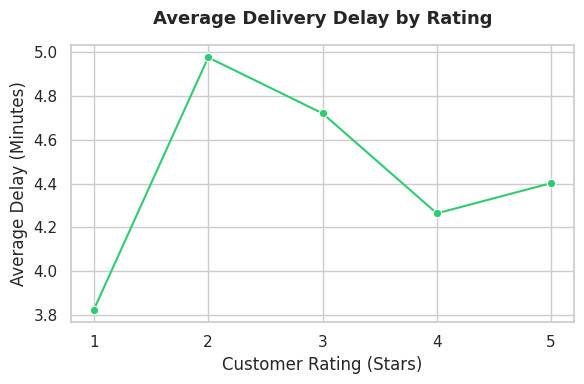

In [68]:
avg_delay_by_rating = orders_experience.groupby('rating')['delay in minutes'].mean().reset_index()

plt.figure(figsize=(6, 4))
sns.set_theme(style="whitegrid")
sns.lineplot(x='rating', y='delay in minutes', data=avg_delay_by_rating, marker='o', color='#2ecc71')
plt.title('Average Delivery Delay by Rating', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Customer Rating (Stars)', fontsize=12)
plt.ylabel('Average Delay (Minutes)', fontsize=12)
plt.xticks(avg_delay_by_rating['rating'])

plt.tight_layout()
plt.show()

### Key Insights: Impact of Delivery Delay on Customer Ratings

Based on the average delay calculation for each rating level, we can observe a clear correlation:

> **Strong Negative Correlation:** There is a direct relationship between delivery delays and low ratings. As the average delay increases, customer satisfaction drops significantly.

> **The 1-Star Threshold:** Orders that received a **1-Star rating** have the highest average delay, indicating that long waiting times are a primary trigger for extreme customer dissatisfaction.

> **On-Time Efficiency:** On the other hand, **4 and 5-Star ratings** show the lowest average delays (closest to zero or even delivered early), proving that on-time delivery is essential for maintaining high retention.

---

**Business Recommendation:** Operations and logistics teams must implement a dynamic alert system for riders when an order exceeds its `promised_delivery_time` by a specific threshold, as cutting down delay minutes will directly shift ratings from low to high.

delivery_status_x
On Time                  2.716441
Significantly Delayed    2.692515
Slightly Delayed         2.735564
Name: distance_km, dtype: float64


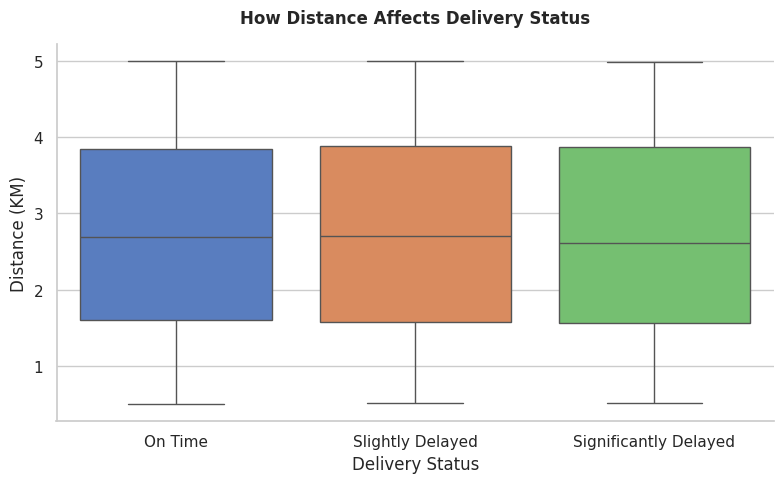

In [69]:
#Study whether orders traveling longer distances suffer from delivery delays or receive customer feedback stating that the product arrived damaged.
print(orders_experience.groupby('delivery_status_x')['distance_km'].mean())

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=orders_experience,
    x='delivery_status_x',
    y='distance_km',
    hue='delivery_status_x',
    palette='muted',
    legend=False
)

plt.title('How Distance Affects Delivery Status', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Delivery Status')
plt.ylabel('Distance (KM)')

sns.despine()
plt.tight_layout()
plt.show()

###Key Insights: How Distance Affects Delivery Status

Based on the boxplot analysis comparing trip distances across different delivery statuses, we can draw the following conclusions:

> **Distance Has No Impact on Delays:** The median delivery distance for all three categories (*On Time*, *Slightly Delayed*, and *Significantly Delayed*) is virtually identical, hovering around **2.7 KM**.

> **Identical Distribution:** The overall spread of delivery distances (from approximately 0.5 KM to 5 KM) remains the same regardless of whether the order arrived on time or faced major delays.

---

**Business Verdict:** This proves that **trip distance (`distance_km`) is NOT the root cause of delivery delays**. A short trip of 1.5 KM has the exact same probability of being delayed as a longer 4.5 KM trip. The operations team should focus on solving external bottlenecks like **traffic congestion** or **order preparation delays at the store** rather than blaming the distance or geographic radius.

Calculating top 5 categories by net profit
              category  actual_profit
0             Pet Care    188961.0625
1  Fruits & Vegetables    139763.2700
2        Personal Care    138213.1135
3    Snacks & Munchies    138127.0485
4    Dairy & Breakfast    127844.4380


Average Discount Percentage Granted per Product Category
                 category  discount_percentage
0   Instant & Frozen Food            39.999794
1       Snacks & Munchies            34.999964
2           Personal Care            34.999919
3                Pet Care            34.999844
4    Cold Drinks & Juices            30.000673
5               Baby Care            30.000063
6     Fruits & Vegetables            25.000384
7          Household Care            25.000025
8       Dairy & Breakfast            19.999935
9                Pharmacy            19.999813
10      Grocery & Staples            15.000241


 The top 5 brands : 
            brand  order_total
0      Mandal-Kar     77830.82
1      Karnik PLC    

/tmp/ipykernel_1795/486400028.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_profit = sales_data.groupby('category')['actual_profit'].sum().sort_values(ascending=False).reset_index()
/tmp/ipykernel_1795/486400028.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_discount = sales_data.groupby('category')['discount_percentage'].mean().sort_values(ascending=False).reset_index()
/tmp/ipykernel_1795/486400028.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observe

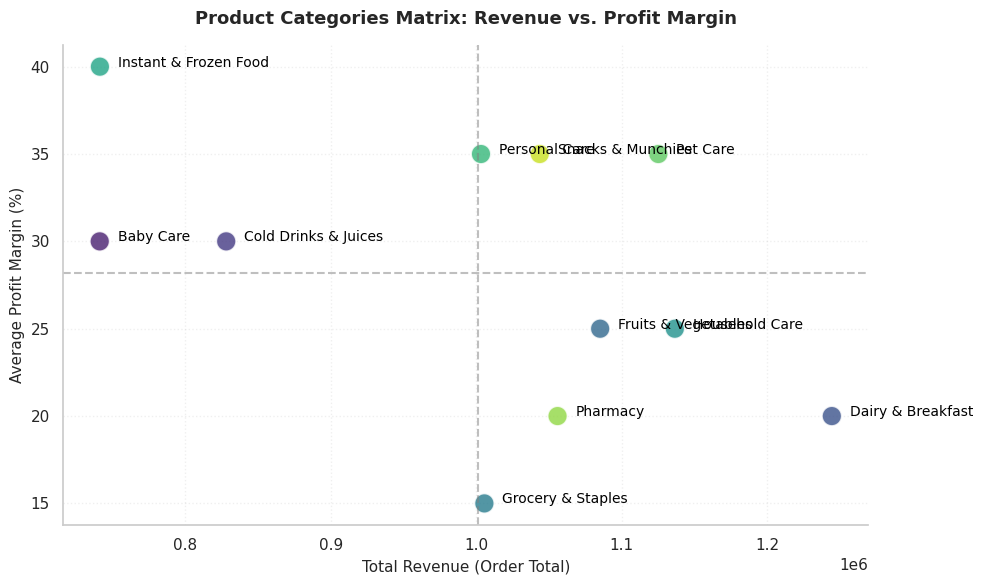

In [80]:
#Profit Margin Analysis

print("Calculating top 5 categories by net profit")

sales_data['actual_profit'] = sales_data['quantity'] * sales_data['unit_price'] * (sales_data['margin_percentage'] / 100)

category_profit = sales_data.groupby('category')['actual_profit'].sum().sort_values(ascending=False).reset_index()
print(category_profit.head(5))
print("\n" + "="*50 + "\n")


print("Average Discount Percentage Granted per Product Category")


sales_data['discount_amount'] = sales_data['mrp'] - sales_data['unit_price']
sales_data['discount_percentage'] = (sales_data['discount_amount'] / sales_data['mrp']) * 100

category_discount = sales_data.groupby('category')['discount_percentage'].mean().sort_values(ascending=False).reset_index()
print(category_discount)
print("\n" + "="*50 + "\n")



print(" The top 5 brands : ")

brand_sales = sales_data.groupby('brand')['order_total'].sum().sort_values(ascending=False).reset_index()
print(brand_sales.head(5))
print("\n" + "="*50 + "\n")



scatter_data = sales_data.groupby('category').agg(
    total_revenue=('order_total', 'sum'),
    avg_margin=('margin_percentage', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))


sns.scatterplot(
    data=scatter_data,
    x='total_revenue',
    y='avg_margin',
    hue='category',
    palette='viridis',
    s=200,
    alpha=0.8
)


for i in range(len(scatter_data)):
    plt.text(
        x=scatter_data['total_revenue'][i] + (scatter_data['total_revenue'].max() * 0.01),
        y=scatter_data['avg_margin'][i],
        s=scatter_data['category'][i],
        fontdict=dict(color='black', size=10)
    )


plt.title('Product Categories Matrix: Revenue vs. Profit Margin', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Total Revenue (Order Total)', fontsize=11)
plt.ylabel('Average Profit Margin (%)', fontsize=11)
plt.legend().remove()


plt.axvline(scatter_data['total_revenue'].mean(), color='grey', linestyle='--', alpha=0.5)
plt.axhline(scatter_data['avg_margin'].mean(), color='grey', linestyle='--', alpha=0.5)

sns.despine()
plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()
plt.show()

### Strategic Business Insights from Sales & Profitability Analysis

#### 1. The Core Profit Engines (Stars)
* `Pet Care` is the undisputed crown jewel of the store, driving the highest net profit of **188.9K** due to its perfect balance of high sales volume and strong profit margins (~35%).
* `Snacks & Munchies` and `Personal Care` closely follow, solidifying this quadrant as the primary source of sustainable business growth.

#### 2. The Volume & Traffic Drivers
* `Dairy & Breakfast` and `Fruits & Vegetables` act as vital customer magnets, generating the highest overall revenue (up to **1.25M**).
* Although their profit margins are lower (20% - 25%), their massive transaction volume successfully converts them into top net profit contributors.

#### 3. The Discount & Margin Paradox
* `Instant & Frozen Food` boasts the highest profit margin in the shop (**40%**), yet it sits in the low-revenue quadrant.
* Interestingly, this category receives the highest average discount (**~40%**). This suggests that high discounts alone aren't driving volume, signaling a need to review product assortment, pricing strategy, or marketing visibility.

#### 4. Top Performing Brands
* Brand loyalty is highly decentralized, with `Mandal-Kar` (**77.8K**) and `Karnik PLC` (**75.3K**) leading the total sales chart. No single brand dominates the platform, indicating a healthy, diversified vendor ecosystem.

In [71]:
order_customer

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,...,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,...,Urishilla Hegde,ydeo@example.org,910400446367,"H.No. 330\nRana Path, Sagar 712033",Allahabad,911359,2024-09-02,Regular,13,749.95
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,...,Ranveer Mahal,phegde@example.org,912292591574,"49, Sarkar Zila, Navi Mumbai-077374",Thrissur,856100,2023-11-07,New,5,958.06
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,...,Aarna Bawa,kondajagdish@example.com,912719661653,"14/351, Agarwal Path\nMedininagar 636193",Vellore,117423,2024-01-05,Inactive,4,327.93
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,...,Aayush Sengupta,lekha10@example.com,913367647372,"20/47\nRatta Chowk, Sonipat-022522",Gaya,288459,2023-12-25,Premium,5,273.38
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,...,Vansha Kuruvilla,xalak62@example.com,912910638833,"H.No. 68, Gaba Road\nKhandwa 040880",Asansol,149383,2024-10-02,Premium,14,763.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1669690997,62600289,2023-12-25 15:46:20,2023-12-25 16:05:20,2023-12-25 16:10:20,On Time,1132.33,Cash,90914,1587,...,Tanmayi Zachariah,aishanikata@example.net,914705136766,"88, Chaudhary Zila, Kalyan-Dombivli 682393",Udaipur,72489,2024-02-20,Inactive,10,1326.02
4996,8340761903,53640286,2023-11-27 09:18:43,2023-11-27 09:38:43,2023-11-27 09:36:43,On Time,2372.01,Cash,27952,3458,...,Quincy Cheema,vigvasatika@example.org,915944903566,"58/738, Dhar Zila, Phusro-372086",Mathura,28426,2023-11-12,Premium,20,1368.38
4997,5936301790,87059497,2024-06-21 19:09:09,2024-06-21 19:23:09,2024-06-21 19:26:09,On Time,3158.35,Cash,9590,7424,...,Abeer Merchant,peterkuruvilla@example.net,910387963526,"H.No. 69, Mangal Zila\nSikar-669273",Jamshedpur,771247,2024-02-09,Regular,5,1137.61
4998,5710579377,67310893,2024-06-06 14:58:13,2024-06-06 15:12:13,2024-06-06 15:10:13,On Time,1918.92,UPI,29940,6128,...,Idika Patla,arya77@example.org,917710512882,"91/165, Dewan Circle\nAjmer-980052",Chennai,286135,2024-04-10,New,19,1592.94


/tmp/ipykernel_1795/1540266973.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = order_customer.groupby('customer_segment')['avg_order_value'].mean().sort_values(ascending=False).reset_index()
/tmp/ipykernel_1795/1540266973.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


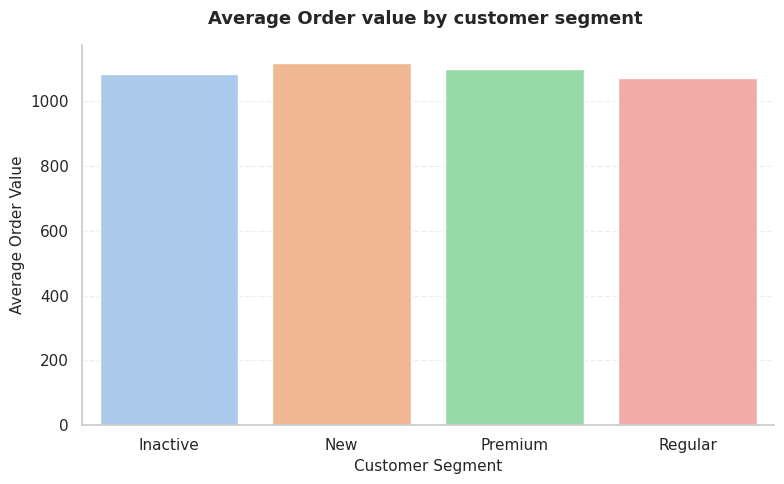

In [72]:
# Idetify which customer segment (Premium , Regular,New, Inactive) spends the most inside the store
# Measure the effectivness of subscriptions  premium and targeted promotions
segment_analysis = order_customer.groupby('customer_segment')['avg_order_value'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8,5))
sns.barplot(
    data=segment_analysis,
    x='customer_segment',
    y='avg_order_value',
    palette='pastel',
    legend=False
)
plt.title('Average Order value by customer segment ',fontsize=13,fontweight='bold',pad=15)
plt.xlabel('Customer Segment',fontsize=11)
plt.ylabel('Average Order Value',fontsize=11)

sns.despine()
plt.grid(axis='y',linestyle='--',alpha=0.3)
plt.tight_layout()
plt.show()

In [73]:
segment_count=order_customer.groupby('customer_segment').agg(
total_order_count=('order_id','count'),
    total_revenue=('order_total','sum')
).reset_index()
segment_count=segment_count.sort_values(by='total_order_count',ascending=False)
print(segment_count.round(2))

  customer_segment  total_order_count  total_revenue
3          Regular               1320     2890148.66
2          Premium               1268     2731329.71
1              New               1222     2795854.48
0         Inactive               1190     2591975.65


/tmp/ipykernel_1795/2744966191.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_count=order_customer.groupby('customer_segment').agg(


###  Key Insights: Customer Segmentation Deep Dive

By looking closely at the total volume and revenue across all customer tiers, we can highlight the following:

> **Balanced Revenue Distribution:** The total revenue and order volume are almost equally distributed among all tiers. *Regular** customers lead slightly with 1,320 orders (~$2.89M), while *Inactive** customers *still *maintain * 1,190 orders (~$2.59M).

---
 the current retention and subscription strategies are completely ineffective, as "Inactive" segments are generating almost the exact same traffic and financial value as "Premium" locked-in subscribers.